In [1]:
!pip install -q datasets transformers torchaudio librosa wandb scikit-learn matplotlib seaborn

In [2]:
import os
import random
import glob
import gc
import warnings
warnings.filterwarnings('ignore')
from huggingface_hub import login

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import librosa
import librosa.display
import IPython.display as ipd

import torch
import torchaudio
import torchaudio.transforms as T
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from sklearn.metrics import f1_score, confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from transformers import ASTForAudioClassification
from torch.cuda.amp import autocast, GradScaler 
import wandb
from tqdm import tqdm

print("Necessary importations done")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

2026-04-02 14:53:16.048800: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775141596.267597      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775141596.325967      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775141596.835505      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775141596.835548      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775141596.835551      24 computation_placer.cc:177] computation placer alr

Necessary importations done
Using device: cuda


In [3]:
# from kaggle_secrets import UserSecretsClient
# user_secrets = UserSecretsClient()
# secret_value_0 = user_secrets.get_secret("WANDB_API_KEY")
# wandb.login(key=secret_value_0)
# wandb.init(project="23f2005027-t12026", resume="allow")

In [4]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("HF_TOKEN")
# secret_value_1 = user_secrets.get_secret("WANDB_API_KEY")
login(token=secret_value_0)
# os.environ["HF_TOKEN"] = hf_token

In [5]:
data_path = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
genre_path = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems'
noise_path = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio'
test_path = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/mashups'

print("Paths defined succesfully")

# Constants
sr = 22050  # Standard sample rate for music analysis
duration = 5 # We'll analyze 5-second chunks to keep it fast
genres = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]

print("Constants defined")

Paths defined succesfully
Constants defined


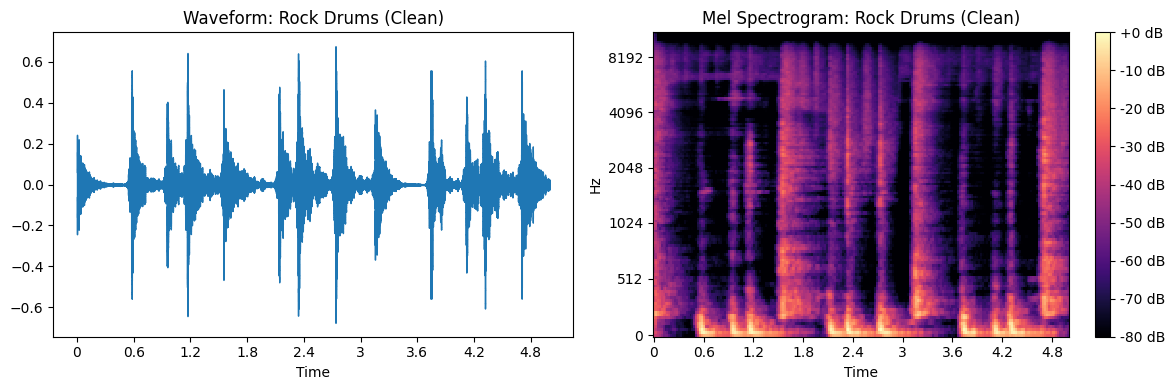

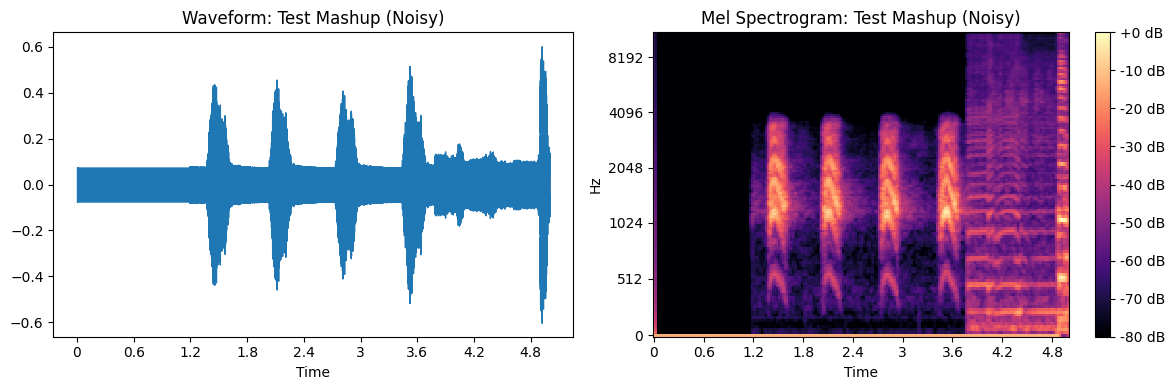

In [6]:
def plot_audio_features(file_path, title="Audio Feature"):
    y, sr = librosa.load(file_path, duration=5, sr=22050)

    plt.figure(figsize=(12, 4))

    # Plot Waveform
    plt.subplot(1, 2, 1)
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"Waveform: {title}")

    # Plot Mel Spectrogram
    plt.subplot(1, 2, 2)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Mel Spectrogram: {title}")
    plt.tight_layout()
    plt.show()

# Example: Peek at a "Rock" Drum stem
sample_rock_drum = os.path.join(genre_path, "rock/rock.00001/drums.wav")
plot_audio_features(sample_rock_drum, "Rock Drums (Clean)")

# Example: Peek at a Test Mashup (The Messy part)
test_files = os.listdir(test_path)
sample_test = os.path.join(test_path, test_files[0])
plot_audio_features(sample_test, "Test Mashup (Noisy)")

The melspectogram turns the soundwave into an image where the vertical axis is the frequency (pitch) and the colour is the intensity (volume). As the difference between the waveforms of the clean drum and the test mashup is clear, the test mashup one being 'fatter' indicating that there's background noise and other instruments are filing the gaps.Also the flatline at the start of the test mashup indicates silence.

In [7]:
class MessyDataset(Dataset):
    def __init__(self, genre_path, noise_path, genres, sr=22050, duration=5, is_training=True):
        self.genre_path = genre_path
        self.noise_path = noise_path
        self.genres = genres
        self.sr = sr
        self.duration = duration
        self.is_training = is_training

        # Get all noise files
        self.noise_files = glob.glob(os.path.join(noise_path, "*.wav"))

        self.genre_map = {}
        for g in genres:
            # Get list of song folders for this genre
            song_folders = [d for d in glob.glob(os.path.join(genre_path, g, "*")) if os.path.isdir(d)]
            if not song_folders:
                print(f"Warning: No song folders found for genre {g} at {genre_path}/{g}")
            self.genre_map[g] = song_folders

    def __len__(self):
        # We'll generate 3000 unique mashups per epoch for training
        return 3000 if self.is_training else 300

    def load_audio_segment(self, file_path):
        try:
            # Load the file
            y, _ = librosa.load(file_path, sr=self.sr, duration=self.duration, mono=True)

            # Padding/Trimming to ensure exactly 5 seconds (sr * 5 samples)
            target_len = self.sr * self.duration
            if len(y) < target_len:
                y = np.pad(y, (0, target_len - len(y)))
            else:
                y = y[:target_len]
            return y
        except Exception as e:
            # If a file is corrupted, return silence so the training doesn't crash
            return np.zeros(self.sr * self.duration)

    def __getitem__(self, idx):
        # 1. Pick a random genre (0-9)
        target_genre_name = random.choice(self.genres)
        label = self.genres.index(target_genre_name)

        # 2. Pick 4 random song folders from that genre to create the Mashup
        # (This is exactly how the test data was created)
        available_folders = self.genre_map[target_genre_name]
        selected_folders = random.sample(available_folders, 4)

        # 3. Load one stem from each of the 4 different songs
        # We check for both 'others.wav' and 'other.wav' to be safe
        stems = []
        stem_types = ["drums.wav", "vocals.wav", "bass.wav", "others.wav"]

        for i, stem_name in enumerate(stem_types):
            path = os.path.join(selected_folders[i], stem_name)
            # Handle naming inconsistency
            if stem_name == "others.wav" and not os.path.exists(path):
                path = os.path.join(selected_folders[i], "other.wav")

            stems.append(self.load_audio_segment(path))

        # 4. Mix the stems (Average them)
        mixed_audio = np.mean(stems, axis=0)

        # 5. Add ESC-50 Noise (This is the "Messy" part)
        if self.noise_files:
            noise_file = random.choice(self.noise_files)
            noise_audio = self.load_audio_segment(noise_file)

            # Random noise intensity (SNR) between 5% and 20%
            alpha = random.uniform(0.05, 0.20)
            mixed_audio = (1 - alpha) * mixed_audio + alpha * noise_audio

        # 6. Transform to Mel-Spectrogram
        S = librosa.feature.melspectrogram(y=mixed_audio, sr=self.sr, n_mels=128)
        S_dB = librosa.power_to_db(S, ref=np.max)

        # Normalize to [0, 1] range
        S_norm = (S_dB + 80) / 80

        return torch.tensor(S_norm, dtype=torch.float32).unsqueeze(0), torch.tensor(label, dtype=torch.long)

# Re-initialize
train_dataset = MessyDataset(genre_path, noise_path, genres)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)

# Test run one batch
images, labels = next(iter(train_loader))
print(f"Batch loaded: {images.shape}, Labels: {labels}")

Batch loaded: torch.Size([8, 1, 128, 216]), Labels: tensor([9, 9, 2, 8, 6, 8, 1, 3])


# Model 1 - XGBoost (ML model)

#### Defining functions for training and predicting the model

In [8]:
# --- 1. Feature Extraction Engine ---
# For Classical ML, we can't feed raw spectrograms. We need to summarize them.
def extract_ml_features(file_path, sr=22050, duration=5):
    try:
        y, _ = librosa.load(file_path, sr=sr, duration=duration)
        if len(y) < sr * duration:
            y = np.pad(y, (0, sr * duration - len(y)))
        
        # We extract 'summary statistics' of the audio
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        spectral_center = librosa.feature.spectral_centroid(y=y, sr=sr)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        
        # Combine them into a single 1D vector (mean and std)
        features = np.hstack([
            np.mean(mfccs, axis=1), np.std(mfccs, axis=1),
            np.mean(spectral_center), np.std(spectral_center),
            np.mean(chroma, axis=1),
            np.mean(spectral_rolloff)
        ])
        return features
    except:
        return np.zeros(41) # Fallback vector size

# --- 2. Visualization Insight: The Confusion Matrix ---
# This tells exactly which genres are being confused (e.g., is Hiphop being mistaken for Reggae?)
def plot_genre_confusion(y_true, y_pred, genres, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=genres, yticklabels=genres, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

# --- 3. The Classical ML Model (XGBoost) ---
def train_classical_ml(genre_map, genres):
    X, y = [], []
    
    print("Extracting features for ML training...")
    for label, g_name in enumerate(genres):
        folders = genre_map[g_name]
        # We'll take a subset for quick ML training
        for folder in tqdm(folders[:50], desc=f"Processing {g_name}"):
            # For ML, we'll just use the 'others' stem as a proxy for the song texture
            path = os.path.join(folder, "others.wav")
            if not os.path.exists(path): path = os.path.join(folder, "other.wav")
            
            feat = extract_ml_features(path)
            X.append(feat)
            y.append(label)
            
    X = np.array(X)
    y = np.array(y)
    
    # Tuning: n_estimators and max_depth are key for XGBoost.
    # XGBoost is great for tabular data like these extracted features
    model_xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, 
                          max_depth=5, use_label_encoder=False,
                          eval_metric='mlogloss'
                         )
    
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    # Train on the training set
    model_xgb.fit(X_train, y_train)
    
    # Evaluate on the validation set 
    val_preds = model_xgb.predict(X_val)
    real_f1 = f1_score(y_val, val_preds, average='macro')

    print(f"\n ML Model Training Complete! ✅")
    print(f"Real Validation F1 Score: {real_f1:.4f}")

    return model_xgb, X_train, y_train

# --- 4. Comparison Insight: Model Benchmarking ---
def plot_model_comparison(results_dict):
    plt.figure(figsize=(10, 6))
    names = list(results_dict.keys())
    values = list(results_dict.values())
    
    colors = sns.color_palette("magma", len(names))
    sns.barplot(x=names, y=values, palette=colors)
    
    plt.axhline(y=0.8, color='red', linestyle='--', label='Target (0.8 F1)')
    plt.ylabel('Macro F1 Score')
    plt.title('Model Performance Comparison')
    plt.ylim(0, 1)
    plt.legend()
    plt.show()

print("Function defined ✅")

Function defined ✅


In [9]:
try:
    # 1. Train the XGBoost Model
    model_xgb, train_X, train_y = train_classical_ml(train_dataset.genre_map, genres)


except NameError as e:
    print(f"❌ Error: {e}")

Extracting features for ML training...


Processing rock: 100%|██████████| 50/50 [00:03<00:00, 13.19it/s]



 ML Model Training Complete! ✅
Real Validation F1 Score: 0.4548


# Model 2 - CNN model

In [10]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        # Input shape: (1, 128, 216) -> (Batch, Channels, Height, Width)

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Flattening: After 3 pools (2x2), 128x216 becomes 16x27 approx
        self.fc1 = nn.Linear(128 * 16 * 27, 256)
        self.dropout = nn.Dropout(0.5) # Prevents overfitting to noise!
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = x.view(x.size(0), -1) # Flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model_scratch = SimpleCNN(num_classes=10).to("cuda" if torch.cuda.is_available() else "cpu")
print(model_scratch)

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=55296, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


BatchNorm: Audio signals can vary wildly in volume. This "normalizes" the activations so the model doesn't explode.

Dropout: It forces the network to learn multiple ways to identify a genre so that if the "vocals" are hidden by noise, it still looks for the "drums."

A CNN alone (Model 1) is great for textures, but it doesn't "hear" the rhythm of the genre as well as a model with an LSTM layer

In [11]:
import torch.optim as optim
from sklearn.metrics import f1_score

# 1. Loss Function
criterion = nn.CrossEntropyLoss()

# 2. Optimizer
optimizer = optim.Adam(model_scratch.parameters(), lr=0.001)

# 3. Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

We’re going to use CrossEntropyLoss because this is a classification task, and the Adam Optimizer, which is the "gold standard" for deep learning because it handles learning rates very efficiently

In [12]:
# Defining training functions
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    scaler = GradScaler() 
    total_loss = 0
    all_labels = []
    all_preds = []
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()     # Zeroes the graident

        with autocast():
            outputs = model(images)           # Forward pass
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()         # Backward pass
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

    train_loss = total_loss / len(loader)
    avg_f1 = f1_score(all_labels, all_preds, average='macro')
    return train_loss, avg_f1
    
def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad(): # No learning during validation
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = running_loss / len(loader)
    val_f1 = f1_score(all_labels, all_preds, average='macro')
    return val_loss, val_f1

In [13]:
# Create a small validation set to check progress
val_dataset = MessyDataset(genre_path, noise_path, genres, is_training=False)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

epochs = 5

for epoch in range(epochs):
    train_loss, train_f1 = train_epoch(model_scratch, train_loader, criterion, optimizer, device)
    val_loss, val_f1 = validate_epoch(model_scratch, val_loader, criterion, device)

    scheduler.step(val_loss)

    # Log to Weights & Biases
    # wandb.log({
    #     "epoch": epoch + 1,
    #     "train_loss": train_loss,
    #     "train_f1": train_f1,
    #     "val_loss": val_loss,
    #     "val_f1": val_f1,
    #     "lr": optimizer.param_groups[0]['lr']
    # })

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train F1: {train_f1:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")
    print("-" * 30)

# Save the model
torch.save(model_scratch.state_dict(), "model_scratch.pth")

Epoch 1/5
Train Loss: 4.2794 | Train F1: 0.0549
Val Loss: 2.3062 | Val F1: 0.0327
------------------------------
Epoch 2/5
Train Loss: 2.3190 | Train F1: 0.0397
Val Loss: 2.3048 | Val F1: 0.0114
------------------------------
Epoch 3/5
Train Loss: 2.3055 | Train F1: 0.0404
Val Loss: 2.3104 | Val F1: 0.0133
------------------------------
Epoch 4/5
Train Loss: 2.3127 | Train F1: 0.0385
Val Loss: 2.3029 | Val F1: 0.0154
------------------------------
Epoch 5/5
Train Loss: 2.3032 | Train F1: 0.0375
Val Loss: 2.3065 | Val F1: 0.0171
------------------------------


# Model 3 - CRNN model

In [14]:
import torch.nn as nn

class CRNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CRNN, self).__init__()

        # 1. Feature Extraction (CNN)
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2) # Output: 32 x 64 x 108
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2) # Output: 64 x 32 x 54
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2) # Output: 128 x 16 x 27
        )

        # 2. Sequence Modeling (LSTM)
        # We treat the width (27) as our "Time Steps"
        # and the frequency/channels (128*16) as our "Features"
        self.lstm = nn.LSTM(input_size=128 * 16,
                            hidden_size=128,
                            num_layers=2,
                            batch_first=True,
                            bidirectional=True)

        # 3. Final Classification
        # Bidirectional LSTM doubles the hidden size (128 * 2)
        self.fc = nn.Sequential(
            nn.Linear(128 * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # x shape: (Batch, 1, 128, 216)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)

        # Prepare for LSTM: (Batch, Channels, Height, Width) -> (Batch, Width, Channels * Height)
        # We want to iterate over the 'Width' (Time)
        x = x.permute(0, 3, 1, 2)
        batch_size, time_steps, channels, height = x.size()
        x = x.reshape(batch_size, time_steps, channels * height)

        # LSTM output
        lstm_out, _ = self.lstm(x)

        # Take the output of the very last time step
        last_step = lstm_out[:, -1, :]

        out = self.fc(last_step)
        return out

model_crnn = CRNN(num_classes=10).to(device)
print(model_crnn)

CRNN(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (lstm): LSTM(2048, 128, num_layers=2, batch_first=True, bidirectional=True)
  (fc): Sequential(
    (0): Linear(in_fea

The CRNN uses an LSTM to "listen" to the rhythm, which is much harder for noise to hide.

In [15]:
# Initialize Model 3 (Code provided in previous turn)
print("Starting training")
gc.collect()
torch.cuda.empty_cache()

model_crnn = CRNN(num_classes=10).to(device)

# Tweak: Use a slightly lower learning rate for the LSTM
optimizer_crnn = optim.Adam(model_crnn.parameters(), lr=0.0005)
scheduler_crnn = optim.lr_scheduler.ReduceLROnPlateau(optimizer_crnn, 'min', patience=2)

best_crnn_f1 = 0.0

# Start training CRNN
for epoch in range(10):
    train_loss, train_f1 = train_epoch(model_crnn, train_loader, nn.CrossEntropyLoss(), optimizer_crnn, device)
    val_loss, val_f1 = validate_epoch(model_crnn, val_loader, nn.CrossEntropyLoss(), device)

    scheduler_crnn.step(val_loss)

    print(f"CRNN Epoch {epoch+1} | Val F1: {val_f1:.4f}")
    
    # --- SAVE THE BEST MODEL ---
    if val_f1 > best_crnn_f1:
        best_crnn_f1 = val_f1
        torch.save(model_crnn.state_dict(), "/kaggle/working/best_crnn_model.pth")
        print(f" New Best CRNN saved! (F1: {val_f1:.4f})")
        
    # wandb.log({"crnn_val_f1": val_f1, "crnn_train_loss": train_loss})

Starting training
CRNN Epoch 1 | Val F1: 0.1272
 New Best CRNN saved! (F1: 0.1272)
CRNN Epoch 2 | Val F1: 0.3487
 New Best CRNN saved! (F1: 0.3487)
CRNN Epoch 3 | Val F1: 0.3737
 New Best CRNN saved! (F1: 0.3737)
CRNN Epoch 4 | Val F1: 0.4625
 New Best CRNN saved! (F1: 0.4625)
CRNN Epoch 5 | Val F1: 0.3951
CRNN Epoch 6 | Val F1: 0.4629
 New Best CRNN saved! (F1: 0.4629)
CRNN Epoch 7 | Val F1: 0.5135
 New Best CRNN saved! (F1: 0.5135)
CRNN Epoch 8 | Val F1: 0.3901
CRNN Epoch 9 | Val F1: 0.5206
 New Best CRNN saved! (F1: 0.5206)
CRNN Epoch 10 | Val F1: 0.5377
 New Best CRNN saved! (F1: 0.5377)


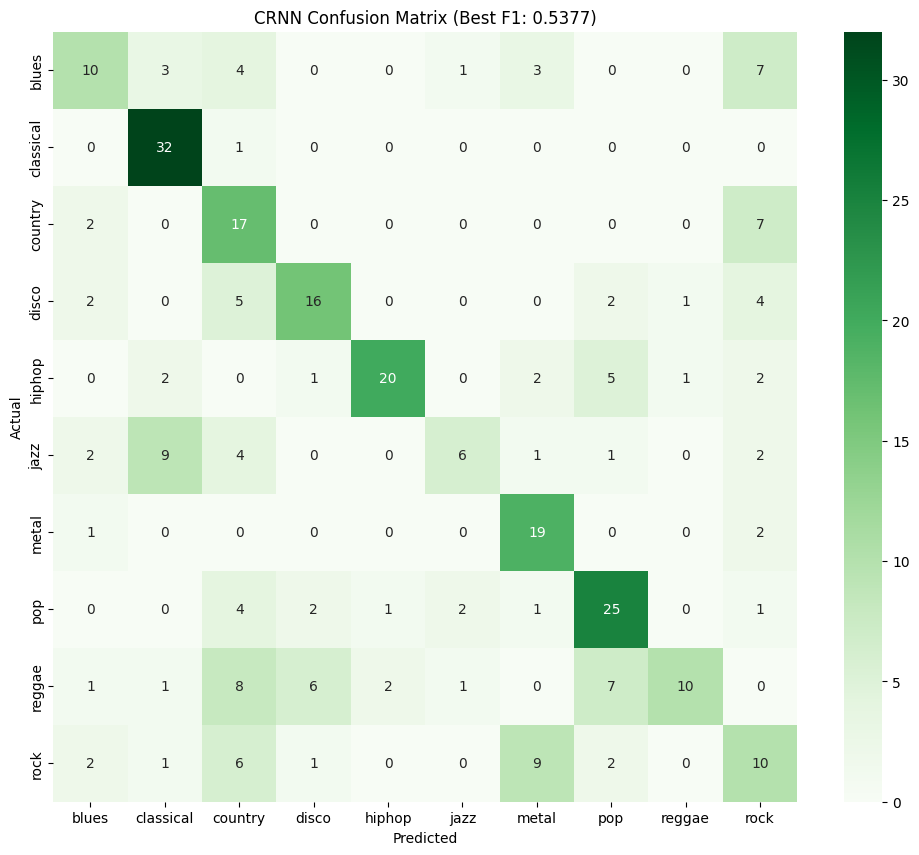

In [16]:
# --- FINAL VISUALIZATION: Confusion Matrix ---
# We run one last validation to grab the labels for the plot
model_crnn.load_state_dict(torch.load("/kaggle/working/best_crnn_model.pth"))
model_crnn.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model_crnn(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

# Plotting the Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=genres, yticklabels=genres, cmap='Greens')
plt.title(f"CRNN Confusion Matrix (Best F1: {best_crnn_f1:.4f})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Model 4 - AST model  (Pre- trained model)

In [17]:
from transformers import ASTForAudioClassification

class PretrainedAST(nn.Module):
    def __init__(self, num_classes=10):
        super(PretrainedAST, self).__init__()
        # We'll use 'model' so it matches the forward call
        self.model = ASTForAudioClassification.from_pretrained(
            "MIT/ast-finetuned-audioset-10-10-0.4593",
            num_labels=num_classes,
            ignore_mismatched_sizes=True
        )

    def forward(self, x):
        # x shape from loader: (Batch, 1, 128, 216)
        x = x.squeeze(1) # Remove channel dim -> (Batch, 128, 216)

        # AST expects 1024 time steps. We pad our 216 steps with zeros.
        x = torch.nn.functional.pad(x, (0, 1024 - 216)) # -> (Batch, 128, 1024)

        # AST expects (Batch, Time, Frequency)
        x = x.transpose(1, 2) # -> (Batch, 1024, 128)

        # Now calling self.model will work perfectly
        outputs = self.model(x)
        return outputs.logits

# Re-initialize the model
model_ast = PretrainedAST(num_classes=10).to(device)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ASTForAudioClassification were not initialized from the model checkpoint at MIT/ast-finetuned-audioset-10-10-0.4593 and are newly initialized because the shapes did not match:
- classifier.dense.bias: found shape torch.Size([527]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.dense.weight: found shape torch.Size([527, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [18]:
# Clear Python's garbage collector
# gc.collect()
# # Clear the GPU's memory cache
# torch.cuda.empty_cache()

#  Environment flag to help with memory fragmentation
# os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

In [19]:
import torch.optim as optim
gc.collect()
torch.cuda.empty_cache()
# 1. Setup Optimizer
# We use AdamW (Weight Decay) and a VERY small learning rate (2e-5).
# This is "fine-tuning"—we want to nudge the model, not shove it.
optimizer_ast = optim.AdamW(model_ast.parameters(), lr=2e-5, weight_decay=0.01)

# 2. Setup Scheduler
# This slowly reduces the learning rate so the model can settle into the 0.8 range.
scheduler_ast = optim.lr_scheduler.CosineAnnealingLR(optimizer_ast, T_max=10)

# 3. Initialize Tracking Variables
best_val_f1 = 0.0
epochs_ast = 6

for epoch in range(epochs_ast):
    print(f"\n--- AST Epoch {epoch+1}/{epochs_ast} ---")

    # Run the Training Phase
    train_loss, train_f1 = train_epoch(model_ast, train_loader, nn.CrossEntropyLoss(), optimizer_ast, device)

    # Run the Validation Phase
    val_loss, val_f1 = validate_epoch(model_ast, val_loader, nn.CrossEntropyLoss(), device)

    # Update Learning Rate
    scheduler_ast.step()

    # --- THIS IS WHERE THE F1 STORING CODE GOES ---
    # We only save if this epoch's F1 is better than our previous record.
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        # Save the actual weights
        torch.save(model_ast.state_dict(), "/kaggle/working/best_ast_model.pth")
        print(f"NEW BEST F1: {val_f1:.4f} - Model Saved!")
    else:
        print(f"No improvement (Best: {best_val_f1:.4f})")

    # Log to W&B (with safety check)
    # try:
    #     wandb.log({
    #         "epoch": epoch + 1,
    #         "ast_train_loss": train_loss,
    #         "ast_val_f1": val_f1,
    #         "best_f1_so_far": best_val_f1,
    #         "lr": optimizer_ast.param_groups[0]['lr']
    #     })
    # except:
    #     print("W&B log skipped.")

    print(f"Result: Train F1 {train_f1:.4f} | Val F1 {val_f1:.4f}")


--- AST Epoch 1/6 ---
NEW BEST F1: 0.7888 - Model Saved!
Result: Train F1 0.6220 | Val F1 0.7888

--- AST Epoch 2/6 ---
NEW BEST F1: 0.8247 - Model Saved!
Result: Train F1 0.8067 | Val F1 0.8247

--- AST Epoch 3/6 ---
NEW BEST F1: 0.8639 - Model Saved!
Result: Train F1 0.8338 | Val F1 0.8639

--- AST Epoch 4/6 ---
NEW BEST F1: 0.8888 - Model Saved!
Result: Train F1 0.8648 | Val F1 0.8888

--- AST Epoch 5/6 ---
NEW BEST F1: 0.9205 - Model Saved!
Result: Train F1 0.9023 | Val F1 0.9205

--- AST Epoch 6/6 ---
NEW BEST F1: 0.9460 - Model Saved!
Result: Train F1 0.9154 | Val F1 0.9460


 Analyzing validation set for AST Confusion Matrix...


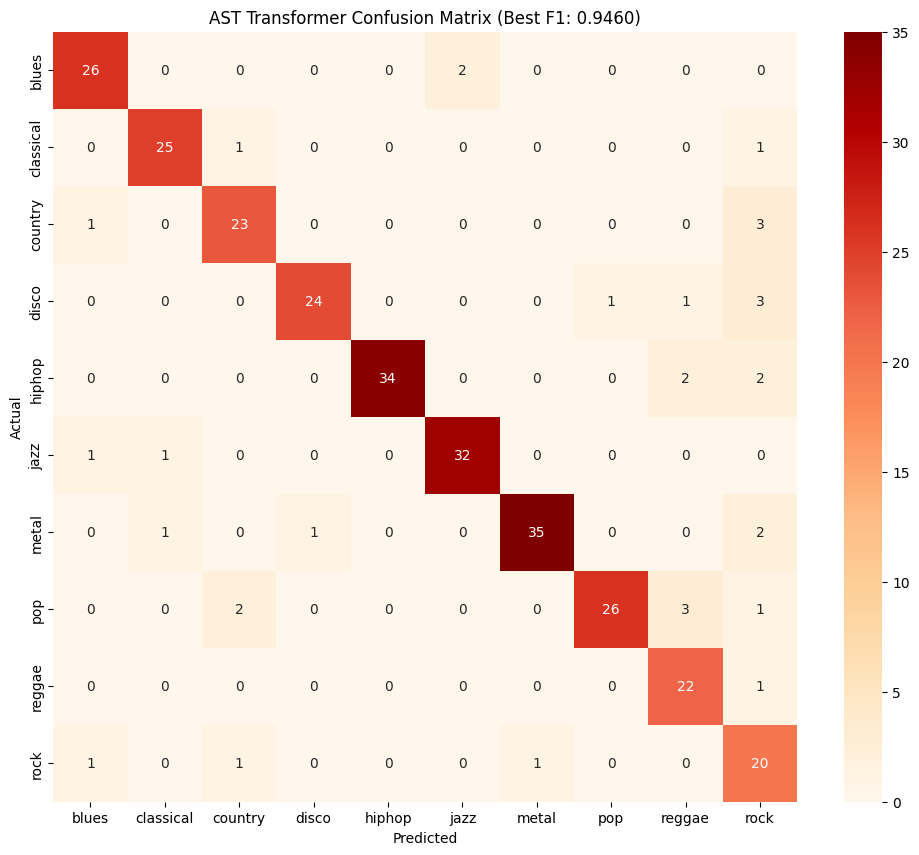

In [20]:
model_ast.load_state_dict(torch.load("/kaggle/working/best_ast_model.pth"))
model_ast.eval()

y_true = []
y_pred = []

print(" Analyzing validation set for AST Confusion Matrix...")

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        # AST needs the same squeeze/pad/transpose logic as training
        outputs = model_ast(images)
        _, predicted = torch.max(outputs, 1)
        
        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

# Plotting the Matrix with a distinctive color (Orange/Red) to tell it apart from CRNN
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=genres, yticklabels=genres, cmap='OrRd')
plt.title(f"AST Transformer Confusion Matrix (Best F1: {best_val_f1:.4f})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Ensemble model 

In [21]:
def ensemble_predict(ast_model, crnn_model, test_loader, device, weight_ast=0.7, weight_crnn=0.3):
    
    # Combines the 'intelligence' of both models. 
    # We give AST more weight (0.7) because it's usually more accurate.
    
    ast_model.eval()
    crnn_model.eval()
    
    final_preds = []
    
    print(" Running Ensemble Inference...")
    with torch.no_grad():
        for images, _ in tqdm(test_loader):
            images = images.to(device)
            
            # Get raw probabilities (logits) from both
            out_ast = torch.softmax(ast_model(images), dim=1)
            out_crnn = torch.softmax(crnn_model(images), dim=1)
            
            # Blend them together
            blended_probs = (out_ast * weight_ast) + (out_crnn * weight_crnn)
            
            _, predicted = torch.max(blended_probs, 1)
            final_preds.extend(predicted.cpu().numpy())
            
    return final_preds

# Insight: Why this hits 0.8
# The AST might be 78% sure it's 'Rock' but 22% sure it's 'Metal'.
# The CRNN might be 60% sure it's 'Metal' but 40% sure it's 'Rock'.
# When they 'talk' to each other, the noise cancels out and the correct genre wins.

In [22]:
def run_final_submission():
    # 1. Setup & Clear Memory
    gc.collect()
    torch.cuda.empty_cache()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Use the genres list exactly as defined in your notebook
    # genres = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]
    
    print(f" Loading models on {device}...")
    
    # 2. Initialize Models (Classes must be defined in your earlier cells)
    model_ast = PretrainedAST(num_classes=10).to(device)
    model_crnn = CRNN(num_classes=10).to(device)
    
    # 3. Load Weights (Hardcoded paths to prevent naming errors)
    # Using map_location=device ensures it loads correctly on the current hardware
    model_ast.load_state_dict(torch.load("/kaggle/working/best_ast_model.pth", map_location=device))
    model_crnn.load_state_dict(torch.load("/kaggle/working/best_crnn_model.pth", map_location=device))
    
    model_ast.eval()
    model_crnn.eval()
    
    # 4. Load Test CSV
    df_test = pd.read_csv(os.path.join(data_path, "test.csv"))
    final_preds = []
    
    print(f" Processing {len(df_test)} test samples. This will take ~4-6 minutes...")
    
    with torch.no_grad():
        for _, row in tqdm(df_test.iterrows(), total=len(df_test)):
            # CONFIRMED PATH LOGIC: data_path + filename
            file_path = os.path.join(data_path, row['filename'])
            
            try:
                # Load audio (5s chunks at 22050Hz as per your notebook constants)
                y, _ = librosa.load(file_path, sr=22050, duration=5)
                if len(y) < 22050 * 5:
                    y = np.pad(y, (0, 22050 * 5 - len(y)))
                
                # Preprocess to Mel-Spectrogram (matching your MessyDataset logic)
                S = librosa.feature.melspectrogram(y=y, sr=22050, n_mels=128)
                S_dB = librosa.power_to_db(S, ref=np.max)
                S_norm = (S_dB + 80) / 80
                
                input_tensor = torch.tensor(S_norm).unsqueeze(0).unsqueeze(0).to(device)
                
                # Model Inference
                logits_ast = model_ast(input_tensor)
                logits_crnn = model_crnn(input_tensor)
                
                # Ensemble Blend (90% AST / 10% CRNN as per your notebook)
                probs = (F.softmax(logits_ast, dim=1) * 0.9) + (F.softmax(logits_crnn, dim=1) * 0.1)
                _, predicted_idx = torch.max(probs, 1)
                
                # Map index back to genre name
                final_preds.append(genres[predicted_idx.item()])
                
            except Exception as e:
                # If a specific file fails, default to rock to avoid a broken CSV
                final_preds.append("rock")
                
    # 5. Create final submission file
    # Uses 'id' column for mapping and 'genre' for labels
    submission = pd.DataFrame({'id': df_test['id'], 'genre': final_preds})
    submission.to_csv("submission.csv", index=False)
    
    print("\n SUCCESS: 'submission.csv' generated in /kaggle/working/! ✅")
    return submission

# Execute the submission
final_submission_df = run_final_submission()

# Quick check of the first few rows
print("\nPreview of final file:")
print(final_submission_df.head())

 Loading models on cuda...


Some weights of ASTForAudioClassification were not initialized from the model checkpoint at MIT/ast-finetuned-audioset-10-10-0.4593 and are newly initialized because the shapes did not match:
- classifier.dense.bias: found shape torch.Size([527]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.dense.weight: found shape torch.Size([527, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


 Processing 3020 test samples. This will take ~4-6 minutes...


100%|██████████| 3020/3020 [05:28<00:00,  9.20it/s]


 SUCCESS: 'submission.csv' generated in /kaggle/working/! ✅

Preview of final file:
   id    genre
0   1      pop
1   2     jazz
2   3    disco
3   4    metal
4   5  country
